

```
`# This is formatted as code`
```

Name : **Deema Mohammed AL-Maqadma** ||
ID : **2320230766** || Presented to : **Eng. Nour Abo Rokb** || Data Science Project-Preprocessing (Titanic)

---



In [ ]:

# Read external dataset (Titanic)
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data_titanic = pd.read_csv(url)

# Show first 10 rows
data_titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:

# Explore Titanic dataset structure
data_titanic.info()
data_titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:

# Handle missing values in Titanic dataset

# Fill missing Age with median
data_titanic['Age'] = data_titanic['Age'].fillna(data_titanic['Age'].median())

# Fill missing Embarked with mode (most frequent value)
data_titanic['Embarked'] = data_titanic['Embarked'].fillna(data_titanic['Embarked'].mode()[0])

# Drop Cabin column (too many missing values)
data_titanic = data_titanic.drop(columns=['Cabin'])

# Remove duplicates if any
data_titanic = data_titanic.drop_duplicates()

# Show dataset info after cleaning
data_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


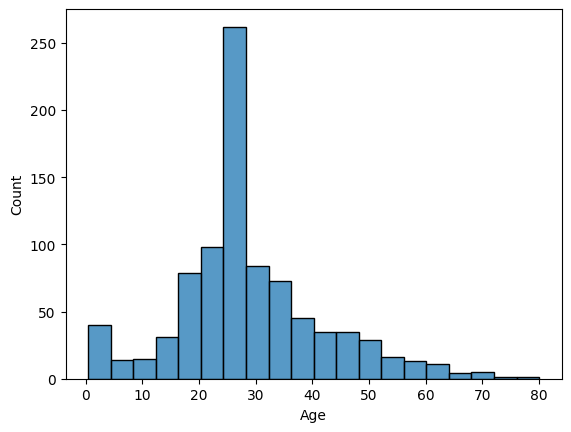

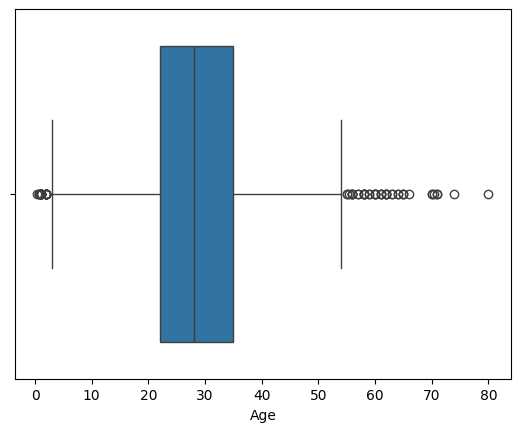

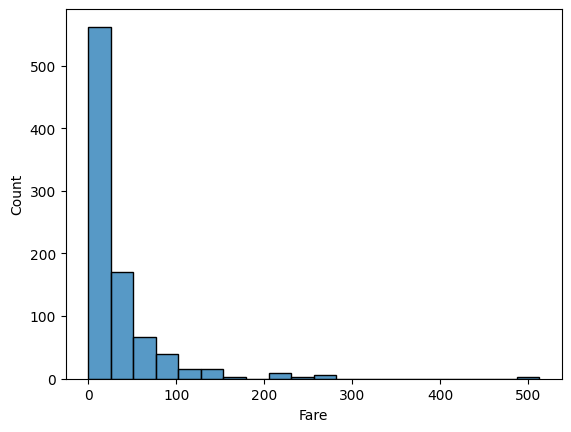

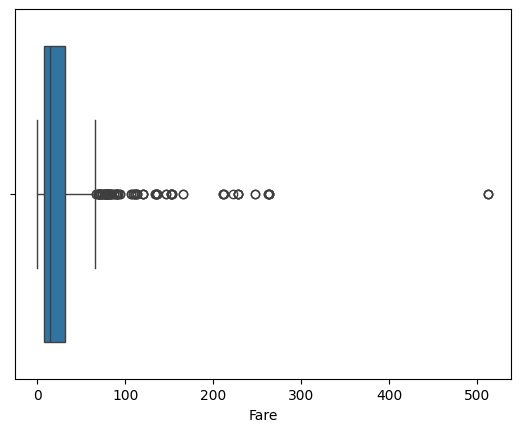

In [ ]:
# Visualization for Age and Fare after cleaning
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram for Age
sns.histplot(data_titanic['Age'], bins=20)
plt.show()

# Boxplot for Age
sns.boxplot(x=data_titanic['Age'])
plt.show()

# Histogram for Fare
sns.histplot(data_titanic['Fare'], bins=20)
plt.show()

# Boxplot for Fare
sns.boxplot(x=data_titanic['Fare'])
plt.show()

In [ ]:
# Normalize Age and Fare columns using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_titanic[['Age_norm','Fare_norm']] = scaler.fit_transform(data_titanic[['Age','Fare']])

# Show first 10 rows after normalization
data_titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_norm,Fare_norm
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0.271174,0.014151
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,0.472229,0.139136
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0.321438,0.015469
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,0.434531,0.103644
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0.434531,0.015713
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,0.346569,0.016510
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,0.673285,0.101229
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,0.019854,0.041136
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,0.334004,0.021731
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,0.170646,0.058694


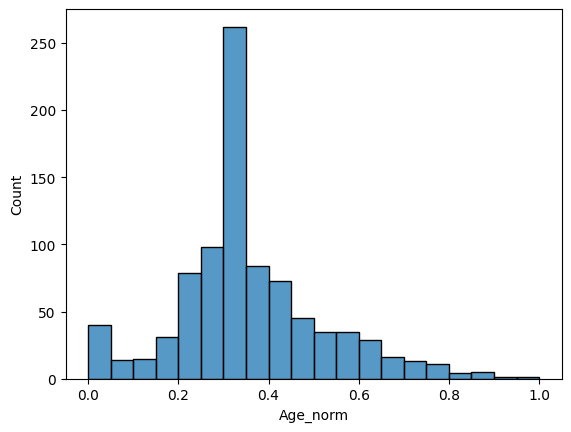

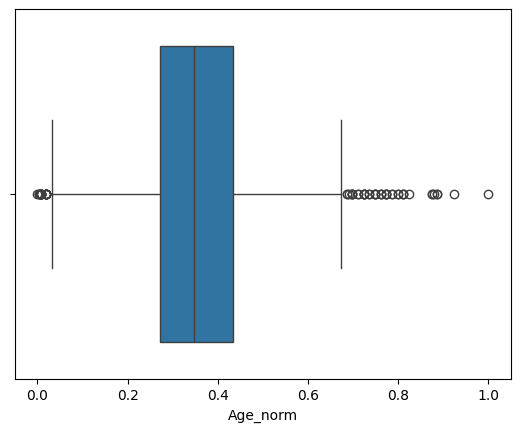

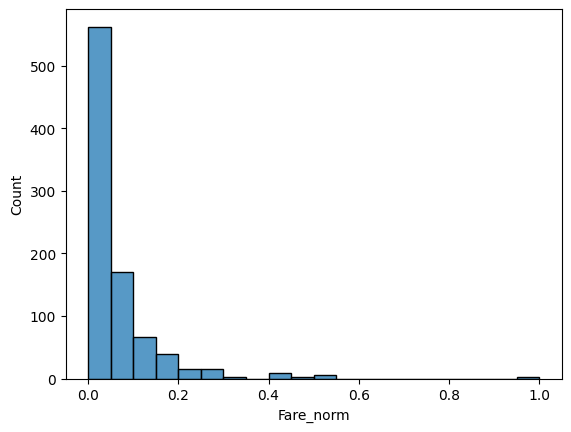

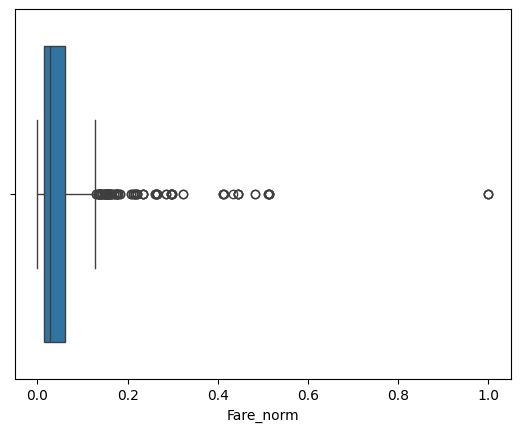

In [ ]:
# Visualization for normalized Age and Fare
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram for Age_norm
sns.histplot(data_titanic['Age_norm'], bins=20)
plt.show()

# Boxplot for Age_norm
sns.boxplot(x=data_titanic['Age_norm'])
plt.show()

# Histogram for Fare_norm
sns.histplot(data_titanic['Fare_norm'], bins=20)
plt.show()

# Boxplot for Fare_norm
sns.boxplot(x=data_titanic['Fare_norm'])
plt.show()

In [ ]:

# Save final cleaned and normalized Titanic dataset
data_titanic.to_csv('/content/drive/MyDrive/titanic_final.csv', index=False)

# Final Summary - Titanic Dataset

## What I did:
- **Loaded dataset** → I imported the Titanic dataset (891 rows × 12 columns).
- **Explored structure** → I checked data types and descriptive statistics, found missing values in Age, Cabin, and Embarked.
- **Cleaned data** → I filled missing Age with median, filled Embarked with mode, and dropped Cabin (too many missing values). I also removed duplicates.
- **Visualization before normalization** → I plotted histograms and boxplots for Age and Fare, saw distributions and clear outliers.
- **Normalization** → I applied MinMaxScaler to Age and Fare, added new columns `Age_norm` and `Fare_norm` scaled between 0–1.
- **Visualization after normalization** → I plotted histograms and boxplots for normalized values, confirmed distributions are preserved but scaled.
- **Saved final dataset** → I exported the cleaned and normalized dataset to `titanic_final.csv`.

## Final results:
- Dataset size: **891 rows × 13 columns** (original + normalized columns).
- `Age` and `Fare` columns: cleaned and normalized.
- Outliers detected: very young/old ages, and high fares above 400.
- Final dataset saved and ready for analysis or submission.